# Real fetal MRI segmentation and growth-chart demonstration

This notebook uses the real 30-week fetal T2 atlas example distributed by FetalSynthSeg, not a synthetic phantom. The image and manual label map originate from the CC0 IMAGINE Fetal T2-weighted MRI Atlas (doi:10.7910/DVN/WE9JVR). The automatic labels are produced by the official FetalSynthSeg checkpoint. Results are research aids, not diagnoses.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display
from fetal_brain_growth.case_report import save_case_report
from fetal_brain_growth.charts import save_growth_chart
from fetal_brain_growth.feta_reference import (
    build_feta_matched_reference, resolve_feta_root, save_feta_matched_reference,
)
from fetal_brain_growth.labels import FETA_MATCHED_REFERENCE_REGIONS, REFERENCE_GROUPS
from fetal_brain_growth.radiology import save_radiology_figure
from fetal_brain_growth.references import build_table_curves, score_against_curves
from fetal_brain_growth.validation import tissue_dice
from fetal_brain_growth.volumetry import measure_segmentation

In [2]:
START = Path.cwd().resolve()
ROOT = next((p for p in (START, *START.parents) if (p/'pyproject.toml').exists() and (p/'notebooks').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Could not locate the fetal-brain-growth repository. Start Jupyter from the repository or its notebooks directory.')
EXAMPLE = ROOT/'third_party/FetalSynthSeg/data/sub-sta30/anat'
IMAGE_PATH = EXAMPLE/'sub-sta30_rec-irtk_T2w.nii.gz'
MANUAL_PATH = EXAMPLE/'sub-sta30_rec-irtk_T2w_dseg.nii.gz'
CHECKPOINT = ROOT/'models/KISPI-all_fss.ckpt'
OUT = ROOT/'demo_outputs/real_example'; OUT.mkdir(parents=True, exist_ok=True)
PREDICTED_PATH = OUT/'sub-sta30_fetalsynthseg.nii.gz'
required = [IMAGE_PATH, MANUAL_PATH] + ([] if PREDICTED_PATH.exists() else [CHECKPOINT])
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError('Run ./scripts/install_fetalsynthseg.sh --accept-license first. Missing: ' + ', '.join(map(str, missing)))
print('Real example:', IMAGE_PATH.name, '• gestational age 30 weeks')

Real example: sub-sta30_rec-irtk_T2w.nii.gz • gestational age 30 weeks


## 1. Run FetalSynthSeg and inspect standard orientation

The wrapper reproduces the official 0.5-mm preprocessing and U-Net, verifies the checkpoint SHA-256 before deserialization, restores labels to native geometry, and records provenance.

Using previously generated prediction: sub-sta30_fetalsynthseg.nii.gz


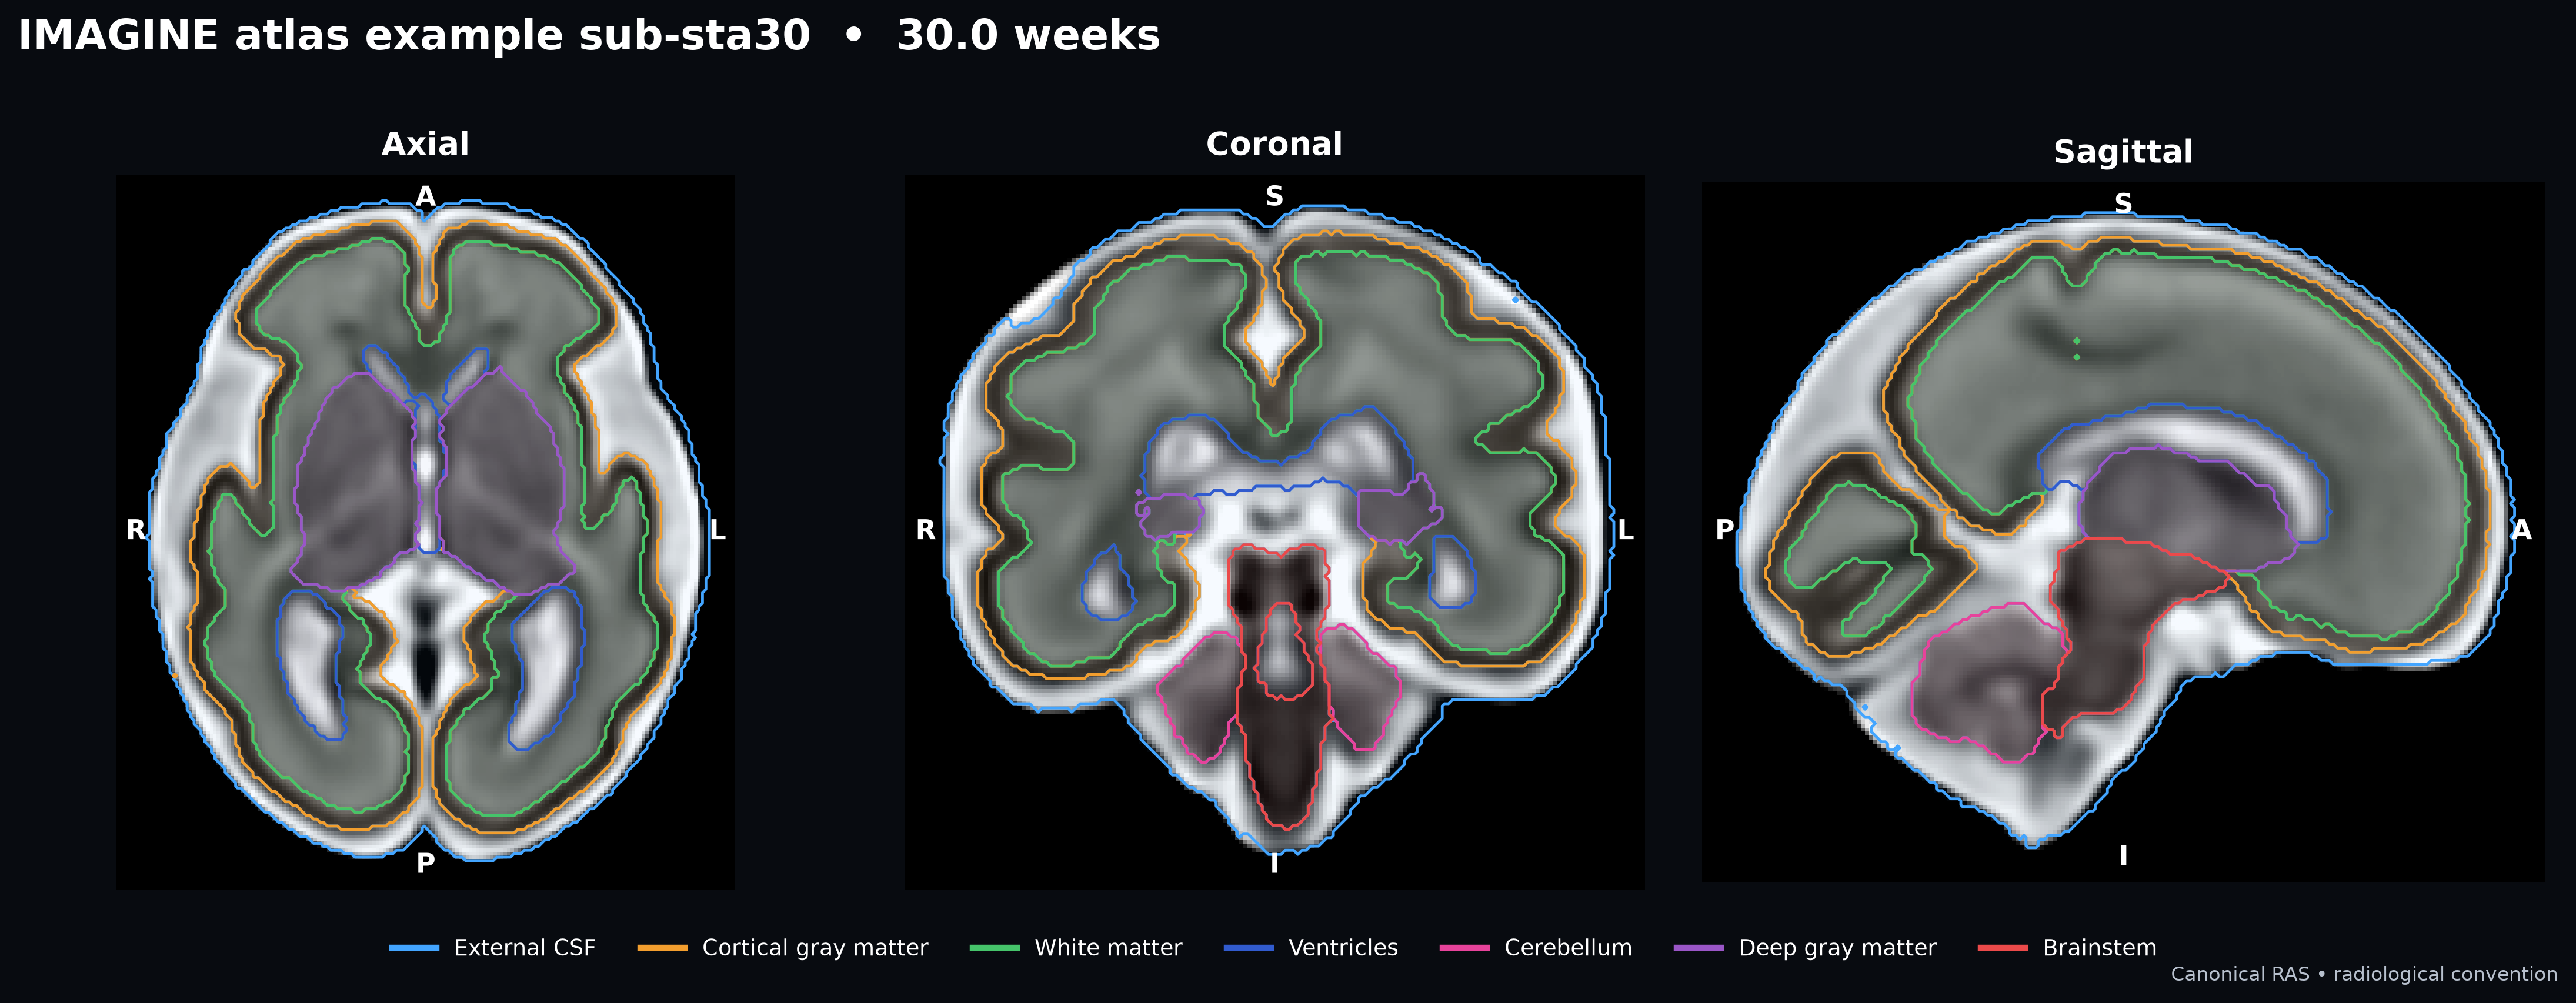

In [3]:
if not PREDICTED_PATH.exists():
    from fetal_brain_growth.segmentation import segment_image
    metadata = segment_image(IMAGE_PATH, PREDICTED_PATH, CHECKPOINT, device_name='auto', metadata_path=OUT/'segmentation_provenance.json')
    public_keys = ('checkpoint_sha256','official_repository','official_commit','device','elapsed_seconds','torch_version','monai_version','intended_use')
    print(json.dumps({key: metadata[key] for key in public_keys}, indent=2))
else:
    print('Using previously generated prediction:', PREDICTED_PATH.name)
qc_figure = save_radiology_figure(IMAGE_PATH, PREDICTED_PATH, OUT/'segmentation_qc.png', subject_id='IMAGINE atlas example sub-sta30', gestational_age_weeks=30.0, fill_alpha=0.05)
display(Image(filename=str(qc_figure), width=1200))

The three panels are reoriented to canonical RAS and shown in radiological convention. Contours preserve the underlying T2 anatomy; patient right appears on image left in axial and coronal views.

## 2. One-case execution validation against the supplied manual labels

Dice here checks model loading, preprocessing, inverse resampling, geometry, and label identity on one real labeled image. It is not a cohort-level accuracy claim.

In [4]:
dice = tissue_dice(PREDICTED_PATH, MANUAL_PATH)
display(dice[['label','tissue','dice','predicted_voxels','manual_voxels']].style.format({'dice':'{:.3f}'}))
print(f"Mean tissue Dice: {dice.dice.mean():.3f}; range {dice.dice.min():.3f}–{dice.dice.max():.3f}")

,label,tissue,dice,predicted_voxels,manual_voxels
0,1,External CSF,0.871,760385,766606
1,2,Cortical gray matter,0.800,403890,510341
2,3,White matter,0.910,785310,739926
3,4,Ventricles,0.685,86836,48144
4,5,Cerebellum,0.925,64346,61194
5,6,Deep gray matter,0.853,87843,90029
6,7,Brainstem,0.811,40887,42726


Mean tissue Dice: 0.836; range 0.685–0.925


## 3. Affine-aware tissue and aggregate volumes

Each volume is `voxel count × abs(det(affine[:3,:3])) / 1000` mL. Native FetalSynthSeg tissues and definition-aware literature aggregates remain separate.

In [5]:
tissues, aggregates, qc = measure_segmentation(PREDICTED_PATH, subject_id='sub-sta30', gestational_age_weeks=30.0)
display(tissues[['label','region','volume_ml']].style.format({'volume_ml':'{:.2f}'}))
display(aggregates[['region','labels','volume_ml']].style.format({'volume_ml':'{:.2f}'}))
qc

,label,region,volume_ml
0,1,external_csf,95.05
1,2,cortical_gray_matter,50.49
2,3,white_matter,98.16
3,4,ventricles,10.85
4,5,cerebellum,8.04
5,6,deep_gray_matter,10.98
6,7,brainstem,5.11


,region,labels,volume_ml
0,total_brain,2+3+5+6+7,172.78
1,intracranial_volume,1+2+3+4+5+6+7,278.69
2,cortical_gray_matter,2,50.49
3,subcortical_brain_tissue,3+6,109.14
4,external_csf,1,95.05
5,ventricles,4,10.85
6,cerebellum,5,8.04
7,brainstem,7,5.11


{'foreground_voxels': 2229497,
 'connected_components': 18,
 'largest_component_fraction': 0.9999869925817348,
 'touches_image_boundary': False,
 'missing_labels': [],
 'warnings': [],
 'subject_id': 'sub-sta30',
 'shape': [256, 256, 256],
 'voxel_volume_ml': 0.00012500000000000003,
 'orientation': 'RAS'}

## 4. Position the real case on multiple quantiles

### Secondary literature comparison: Ren 2022 summary-data reconstruction

These bands are **reconstructed centiles**, not quantiles directly fitted from the individual participants in this notebook and not confidence intervals around the mean. For each of the eight Ren measures, the repository contains the paper's weekly mean `μ(t)` and SD `σ(t)`. For quantile `q`, the curve is

`Q_q(t) = max(0, μ(t) + Φ⁻¹(q) × σ(t))`.

The displayed values are P3/P10/P25/P50/P75/P90/P97. The default `interpolate` method linearly interpolates mean and SD between completed weeks on a 0.05-week grid, preserving the published integer-week values. At 30 weeks, for example, Ren total-brain mean = 175.60 mL and SD = 6.09 mL, giving approximately P3 = 164.1, P10 = 167.8, P25 = 171.5, P50 = 175.6, P75 = 179.7, P90 = 183.4, and P97 = 187.1 mL.

With `quadratic` or `cubic`, mean is fitted in volume space and log(SD) is fitted polynomially so SD stays positive. `auto` uses leave-one-week-out error and selects cubic only when its combined normalized score improves by more than 5%. Published mean-curve coefficients alone do not define centiles. The current public demo uses Ren 2022, not the BMJ Fetal & Neonatal paper.

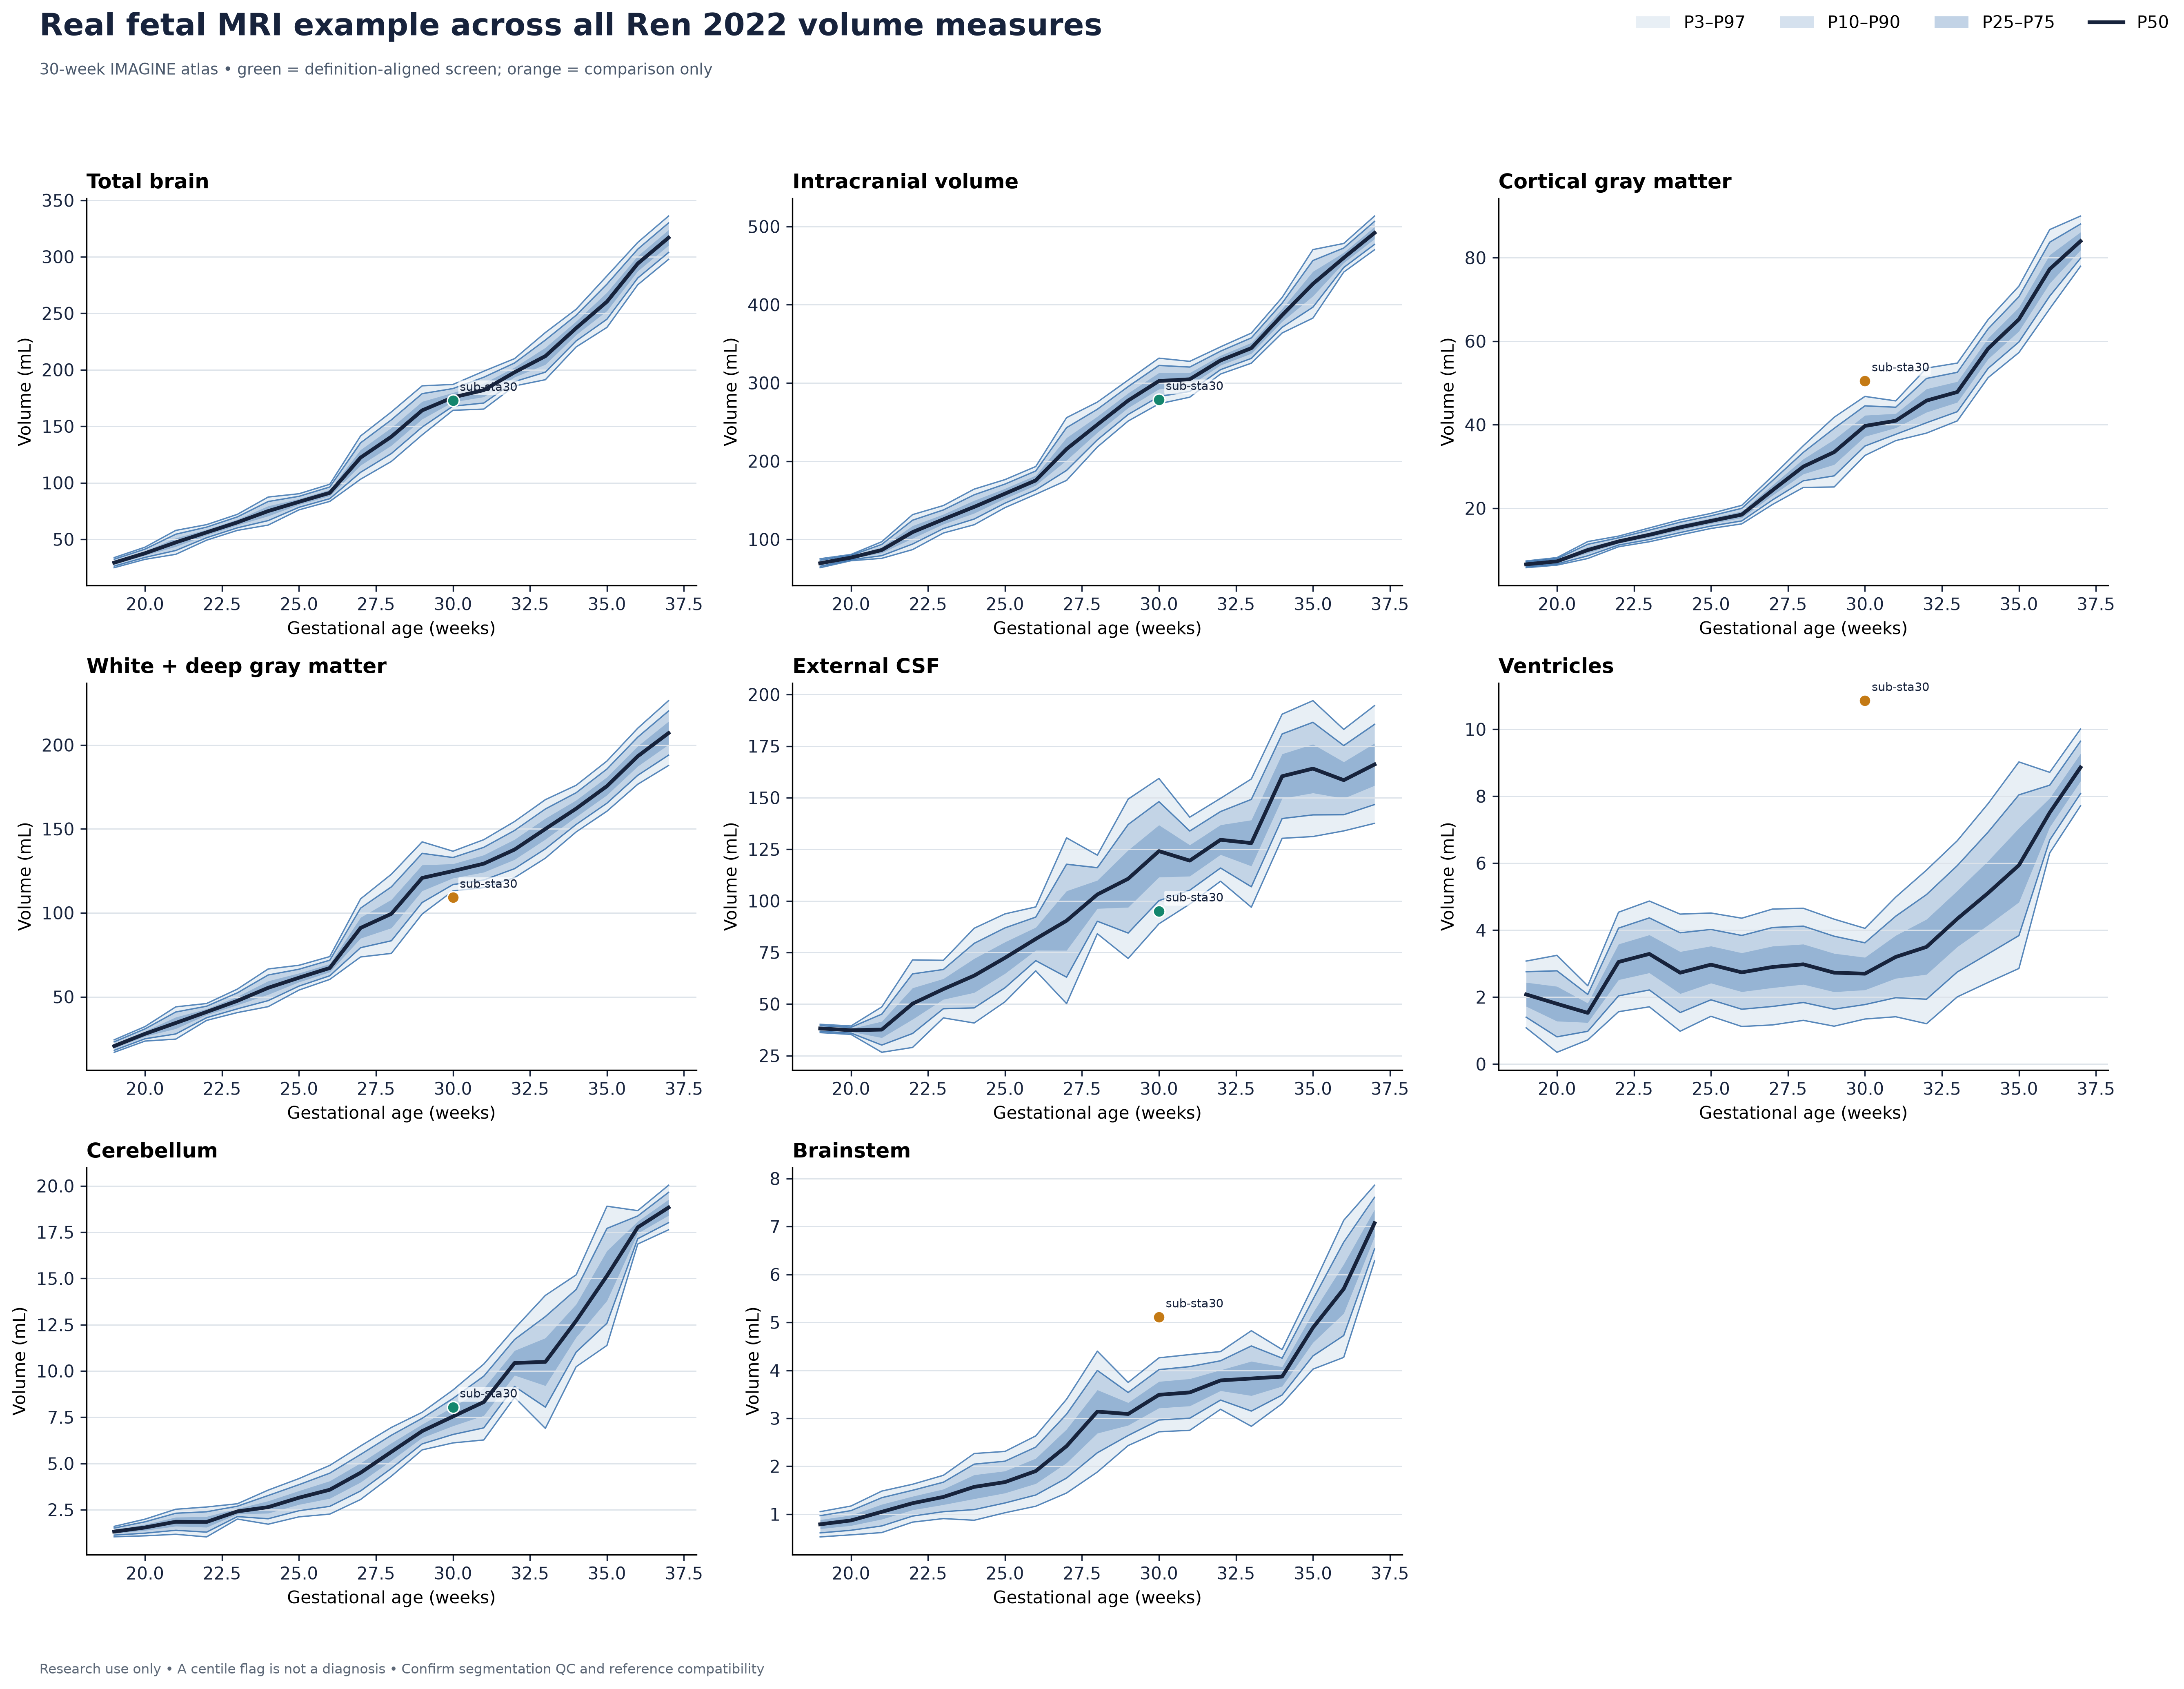

,region,volume_ml,estimated_percentile_bounded,status,interpretation_note
0,total_brain,172.784500,32.864259,within_reference_interval,Definition-aligned research comparison; local ...
1,intracranial_volume,278.687125,7.035577,within_reference_interval,Definition-aligned research comparison; local ...
2,cortical_gray_matter,50.486250,97.000000,comparison_only_definition_mismatch,FeTA and reference cortical boundaries differ.
3,subcortical_brain_tissue,109.144125,3.000000,comparison_only_definition_mismatch,White/deep-gray allocation differs between pro...
4,external_csf,95.048125,6.851433,within_reference_interval,Definition-aligned research comparison; local ...
5,ventricles,10.854500,97.000000,comparison_only_definition_mismatch,The reference measures lateral ventricles; FeT...
6,cerebellum,8.043250,74.543407,within_reference_interval,Definition-aligned research comparison; local ...
7,brainstem,5.110875,97.000000,comparison_only_definition_mismatch,FeTA may include spinal cord with brainstem.


In [6]:
curves, curve_metadata = build_table_curves(method='interpolate')
scores = score_against_curves(aggregates, curves)
chart = save_growth_chart(curves, OUT/'growth_chart.png', observations=scores, regions=tuple(REFERENCE_GROUPS), title='Real fetal MRI example across all Ren 2022 volume measures', subtitle='30-week IMAGINE atlas • green = definition-aligned screen; orange = comparison only')
display(Image(filename=str(chart), width=1200))
display(scores[['region','volume_ml','estimated_percentile_bounded','status','interpretation_note']])

### Case position and reference flags

At the fetus's exact gestational age, each expected quantile is interpolated from the curve. The reported percentile is then linearly interpolated between the seven quantile values and is **bounded to P3–P97**: `P3 bounded` means P3 or lower and `P97 bounded` means P97 or higher, not an exact tail probability. A research flag is produced below P3 or above P97. All eight measures are plotted, but only total brain, intracranial volume, external CSF, and cerebellum are definition-aligned enough for automated Ren flags; the four orange points are comparison-only because anatomical definitions differ.

## 5. Primary local reference: FeTA-generated matched quantiles

For FetalSynthSeg/FeTA-label analysis, this is the preferred local teaching comparison because its nine regions use the same label ontology. It uses 30 QC-passing expert segmentations labeled neurotypical, 22.7–34.8 weeks, with a quadratic centered-age model in log-volume space and a constant log-residual SD. Its quantiles are `Q_q(GA) = exp(fitted_log_volume(GA) + Φ⁻¹(q) × residual_SD)`. Unlike the Ren comparison, all nine panels use the native FeTA/FetalSynthSeg label definitions.

The plot is generated when a cached local fit or the mounted FeTA dataset is available. It contains only aggregate quantile curves and the public IMAGINE atlas observation—no FeTA subject image. This small, partly in-sample reference is for teaching, not a validated clinical norm.

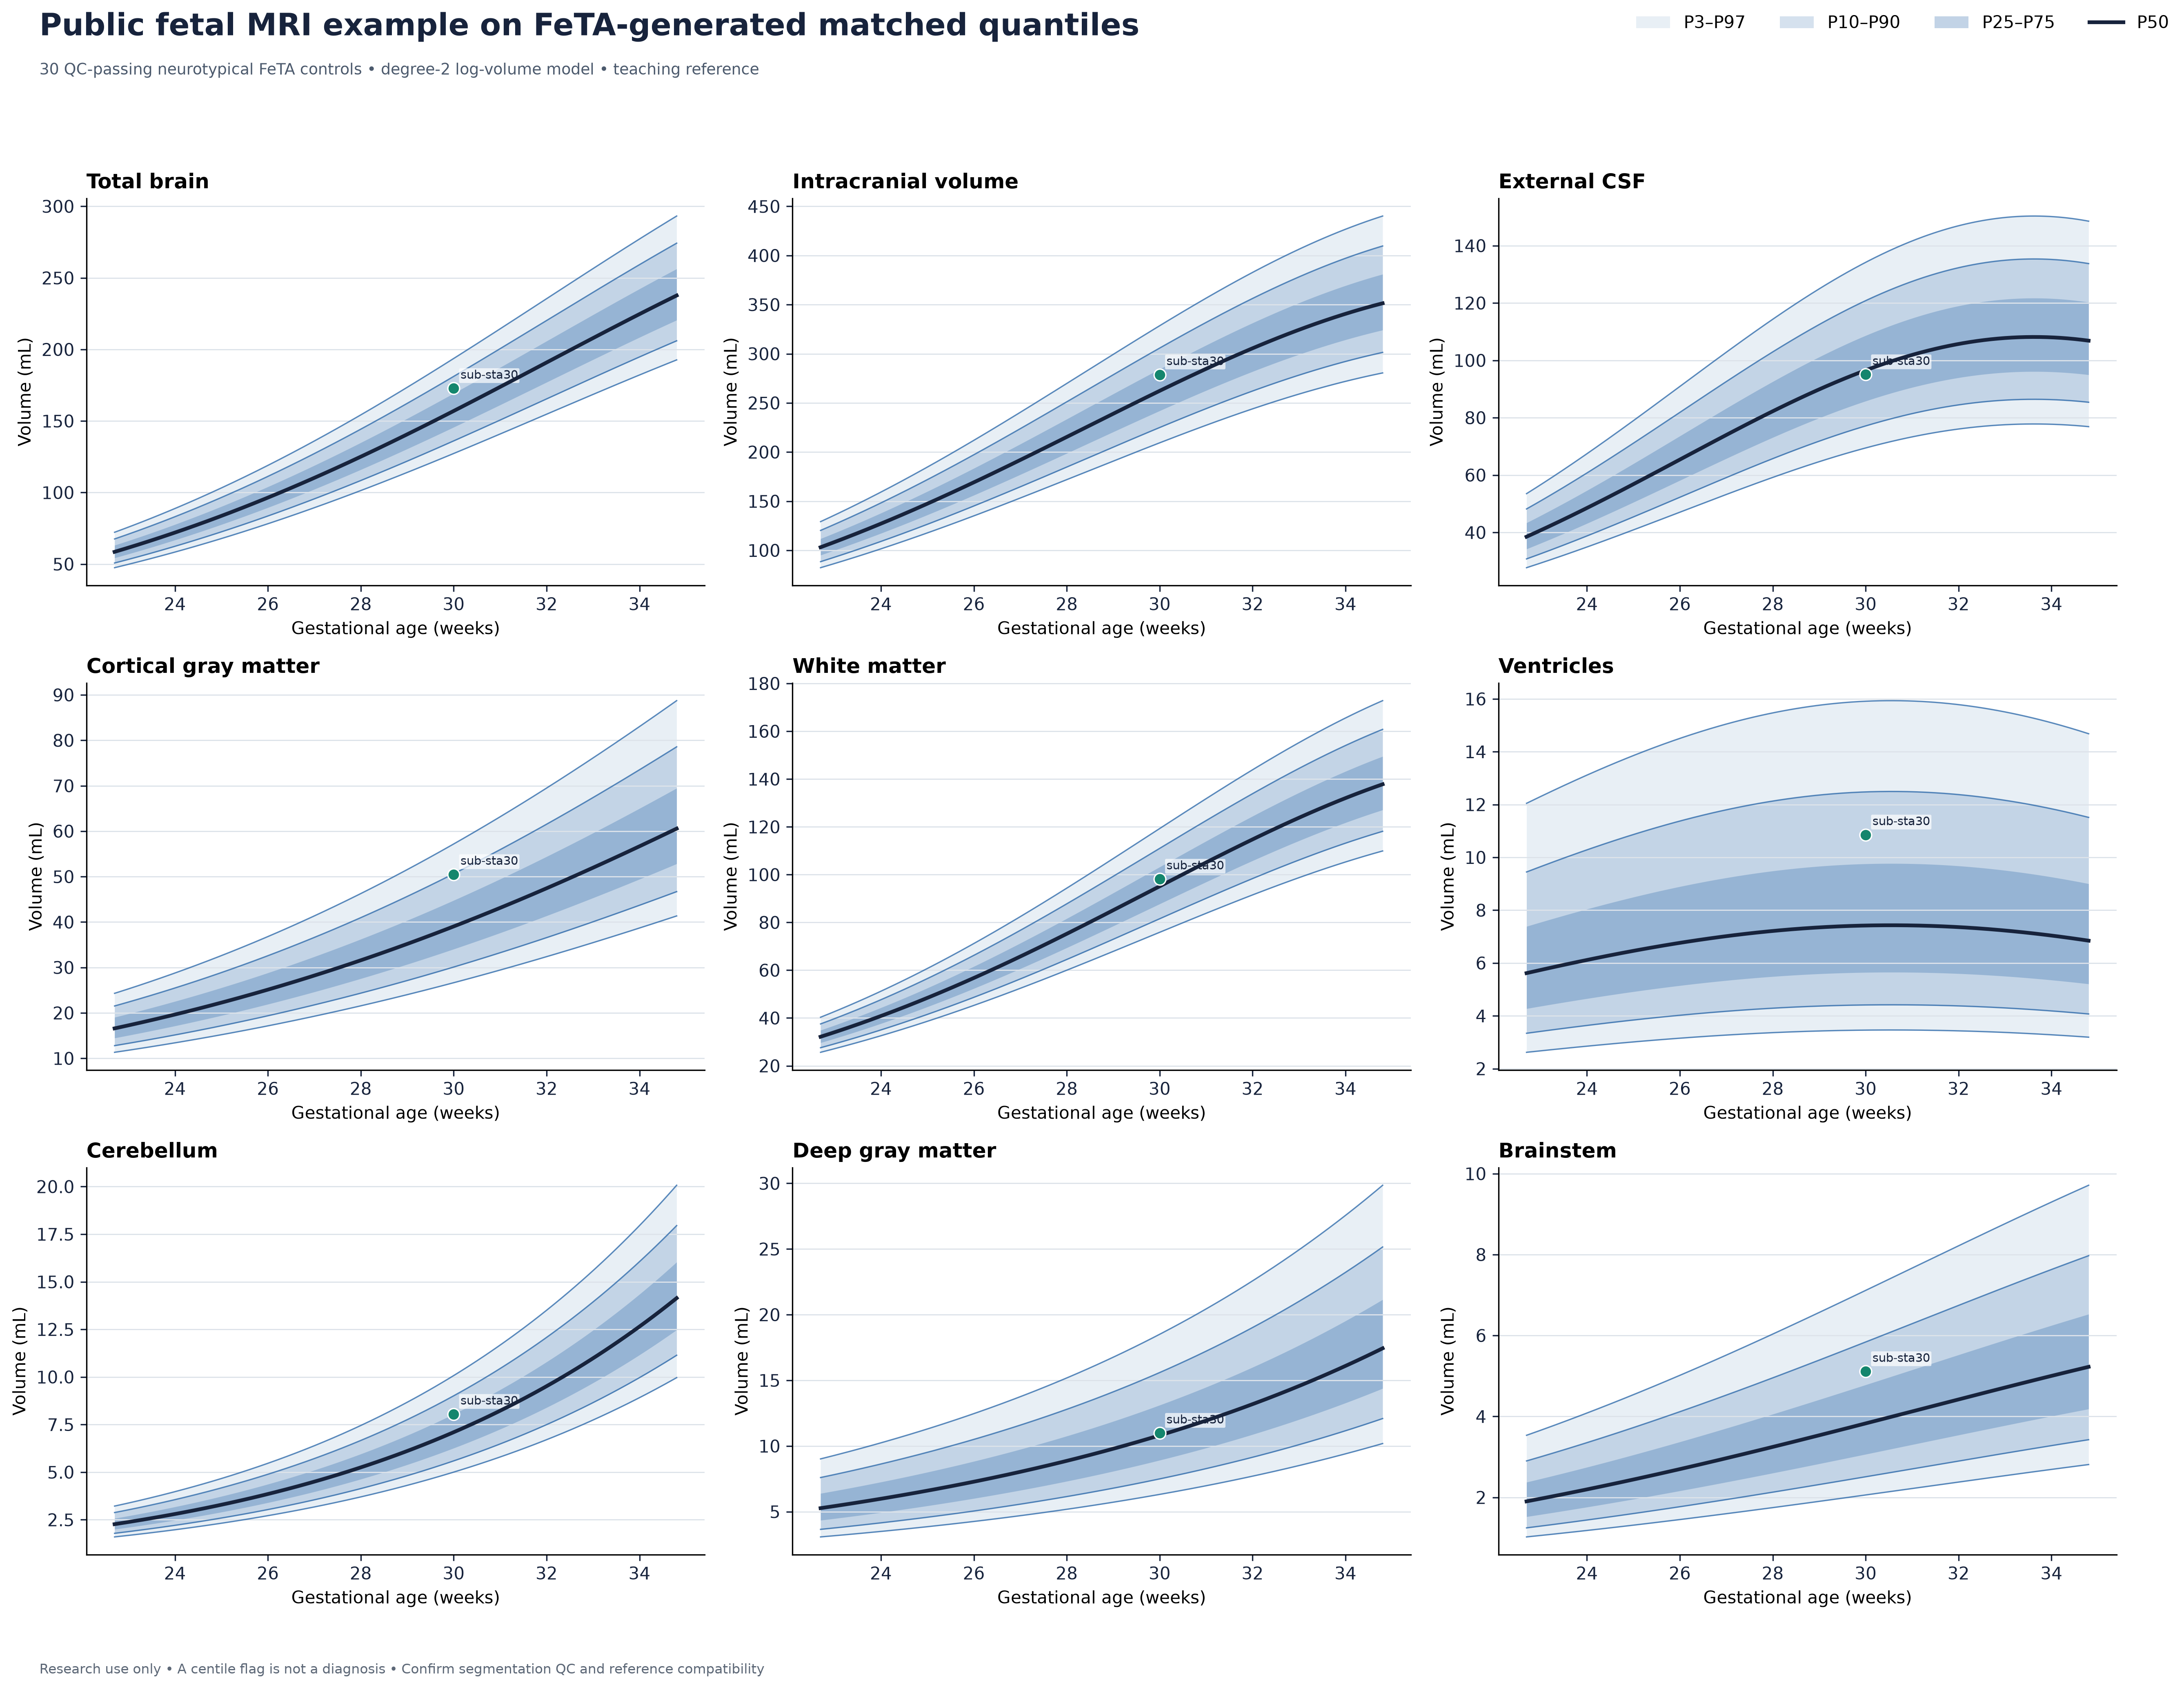

,region,volume_ml,estimated_percentile_bounded,status
0,total_brain,172.784500,79.440607,within_reference_interval
1,intracranial_volume,278.687125,68.563862,within_reference_interval
2,external_csf,95.048125,46.521393,within_reference_interval
3,cortical_gray_matter,50.486250,89.618084,within_reference_interval
4,white_matter,98.163750,59.418582,within_reference_interval
5,ventricles,10.854500,81.056123,within_reference_interval
6,cerebellum,8.043250,74.900751,within_reference_interval
7,deep_gray_matter,10.980375,51.851428,within_reference_interval
8,brainstem,5.110875,79.674427,within_reference_interval


In [7]:
FETA_REFERENCE_DIR = ROOT/'meeting_outputs/feta_10_cases_matched'
FETA_CURVES_PATH = FETA_REFERENCE_DIR/'feta_neurotypical_reference_curves.csv'
FETA_METADATA_PATH = FETA_REFERENCE_DIR/'feta_neurotypical_reference_metadata.json'
feta_curves = feta_metadata = None
if FETA_CURVES_PATH.exists() and FETA_METADATA_PATH.exists():
    feta_curves = pd.read_csv(FETA_CURVES_PATH)
    feta_metadata = json.loads(FETA_METADATA_PATH.read_text())
else:
    try:
        feta_root = resolve_feta_root()
    except FileNotFoundError:
        feta_root = None
    if feta_root is not None:
        feta_curves, feta_metadata, control_tissues, control_volumes, control_qc = build_feta_matched_reference(feta_root, degree=2)
        save_feta_matched_reference(FETA_REFERENCE_DIR, feta_curves, feta_metadata, control_tissues, control_volumes, control_qc)
if feta_curves is None:
    display(Markdown('**FeTA quantile plot skipped:** mount FeTA 2.2 or copy a generated FeTA reference into `meeting_outputs/feta_10_cases_matched/`. The Ren demonstration above remains fully reproducible from public files.'))
else:
    feta_case_volumes = pd.concat([
        aggregates[aggregates.region.isin(['total_brain','intracranial_volume'])],
        tissues,
    ], ignore_index=True, sort=False)
    feta_scores = score_against_curves(feta_case_volumes, feta_curves, definition_guard=False)
    feta_chart = save_growth_chart(
        feta_curves, OUT/'growth_chart_feta_neurotypical.png', observations=feta_scores,
        regions=FETA_MATCHED_REFERENCE_REGIONS,
        title='Public fetal MRI example on FeTA-generated matched quantiles',
        subtitle=f"{feta_metadata['subjects']} QC-passing neurotypical FeTA controls • degree-{feta_metadata['degree']} log-volume model • teaching reference",
        dpi=300,
    )
    display(Image(filename=str(feta_chart), width=1200))
    display(feta_scores[['region','volume_ml','estimated_percentile_bounded','status']])

## 6. Primary-reference radiology case report

When the FeTA-matched reference is available, this report uses its nine definition-compatible panels. Ren is used only as a fallback when the local FeTA fit is unavailable.

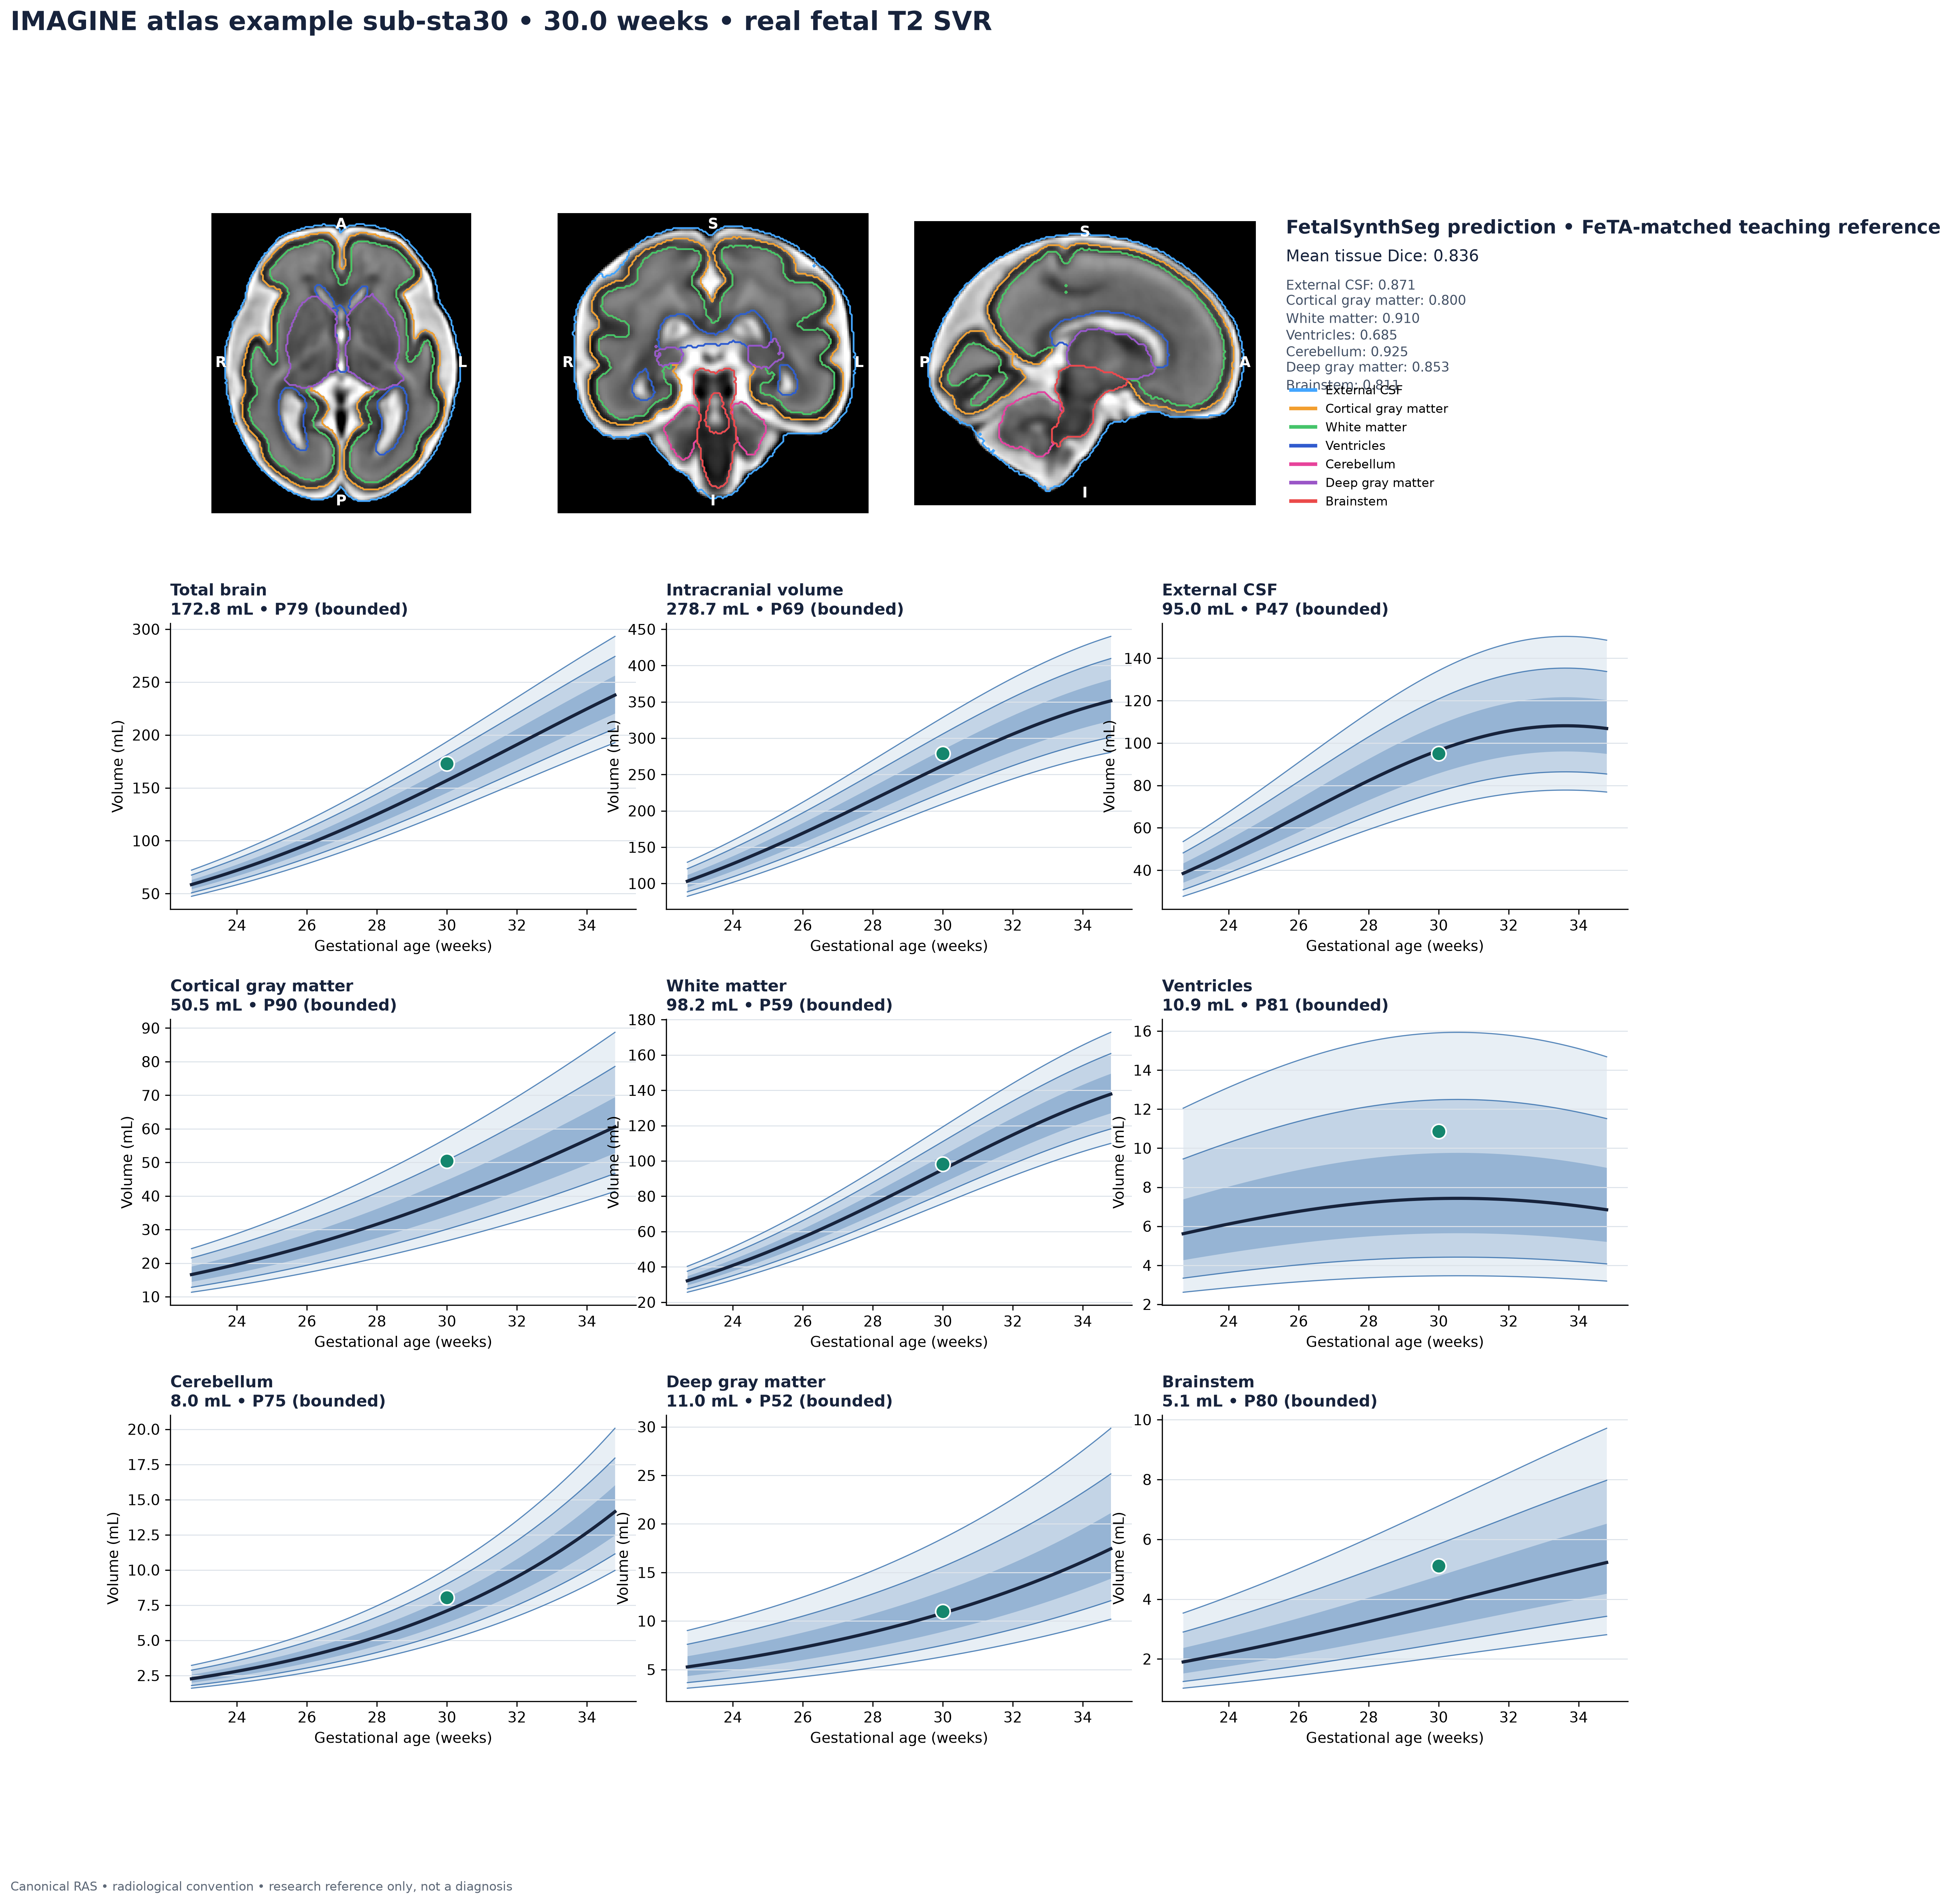

In [8]:
if feta_curves is not None:
    report_curves, report_scores = feta_curves, feta_scores
    report_regions = tuple(FETA_MATCHED_REFERENCE_REGIONS)
    report_reference = 'FeTA-matched teaching reference'
else:
    report_curves, report_scores = curves, scores
    report_regions = tuple(REFERENCE_GROUPS)
    report_reference = 'Ren 2022 compatibility-limited comparison'
report = save_case_report(IMAGE_PATH, PREDICTED_PATH, report_curves, report_scores, OUT/'case_report.png', subject_id='IMAGINE atlas example sub-sta30', gestational_age_weeks=30.0, dice=dice, segmentation_source=f'FetalSynthSeg prediction • {report_reference}', regions=report_regions)
display(Image(filename=str(report), width=1400))

## Interpretation and model choices

- A single scan is a cross-sectional position, not that fetus's longitudinal growth trajectory.
- A reference flag is not an abnormality diagnosis, and within-range volume does not exclude abnormal morphology.
- `interpolate` preserves published weekly means; `quadratic`, `cubic`, and leave-one-week-out `auto` are available.
- The FeTA-generated chart is label-compatible but small and partly in-sample; prefer a larger reviewed cohort processed with the same frozen FetalSynthSeg model for validation.
- Review the complete 3-D MRI/segmentation and clinical context with a fetal neuroradiologist.